In [68]:
## Import the various modules
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mtick

import warnings
warnings.filterwarnings('ignore')



In [69]:
%pip install --upgrade scikit-learn
%pip install --upgrade scikit-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [70]:
!pip install networkx


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [71]:
csv_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/historical_stock_data_full.csv'

In [72]:
# Kiểm tra số liệu

df_week2 = pd.read_csv(csv_path)
print("5 hàng đầu tiên của DataFrame:")
display(df_week2.head())

5 hàng đầu tiên của DataFrame:


,Date,Open,High,Low,Close,Volume,symbol
0,2021-01-04,10.07,10.32,10.07,10.32,2800,DPP
1,2021-01-05,10.27,10.27,10.27,10.27,100,DPP
2,2021-01-06,10.27,10.27,10.27,10.27,0,DPP
3,2021-01-07,10.27,10.27,10.27,10.27,0,DPP
4,2021-01-08,10.27,10.27,10.27,10.27,0,DPP


In [73]:
# Lọc danh mục cổ phiếu theo mã để phân tích
selected_symbols = ['MHC', 'MBB', 'FRT', 'HAH', 'VGI', 'KDH']

symbol_col = next((c for c in df_week2.columns if c.lower() in ['symbol', 'ticker', 'code', 'stock']), None)

df_portfolio = df_week2[df_week2[symbol_col].isin(selected_symbols)].copy()
print('Số lượng bản ghi trong danh mục:', len(df_portfolio))
print('Các mã xuất hiện trong danh mục:')
print(sorted(df_portfolio[symbol_col].unique()))

display(df_portfolio.head())

Số lượng bản ghi trong danh mục: 7481
Các mã xuất hiện trong danh mục:
['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']


,Date,Open,High,Low,Close,Volume,symbol
415838,2021-01-04,18.31,18.40,18.05,18.23,1284600,KDH
415839,2021-01-05,18.13,18.31,18.05,18.25,886200,KDH
415840,2021-01-06,18.25,19.12,18.25,18.62,1741400,KDH
415841,2021-01-07,18.68,19.05,18.62,18.80,1646400,KDH
415842,2021-01-08,18.99,19.05,18.65,18.94,1314900,KDH


In [74]:
# Check available columns and data
print("Available columns:", df_portfolio.columns.tolist())
print("\nUnique symbols:", df_portfolio[symbol_col].unique())
print("\nData types:")
print(df_portfolio.dtypes)

Available columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'symbol']

Unique symbols: <StringArray>
['KDH', 'MHC', 'HAH', 'VGI', 'FRT', 'MBB']
Length: 6, dtype: str

Data types:
Date          str
Open      float64
High      float64
Low       float64
Close     float64
Volume      int64
symbol        str
dtype: object


In [75]:
# Tính tỷ suất sinh lời theo giá Close
# Chuyển cột Date về datetime và sắp xếp theo mã cổ phiếu và ngày

df_portfolio['Date'] = pd.to_datetime(df_portfolio['Date'])
df_portfolio.sort_values([symbol_col, 'Date'], inplace=True)

df_portfolio['Close'] = pd.to_numeric(df_portfolio['Close'], errors='coerce')

df_portfolio['ret_simple'] = df_portfolio.groupby(symbol_col)['Close'].transform('pct_change')
# Log-returns thuận tiện cho các mô hình thống kê
df_portfolio['ret_log'] = df_portfolio.groupby(symbol_col)['Close'].transform(lambda x: np.log(x) - np.log(x.shift(1)))

print('Các cột mới vừa được thêm:')
print(df_portfolio[['Date', symbol_col, 'Close', 'ret_simple', 'ret_log']].head(10))

Các cột mới vừa được thêm:
             Date symbol  Close  ret_simple   ret_log
698181 2021-01-04    FRT  14.81         NaN       NaN
698182 2021-01-05    FRT  14.99    0.012154  0.012081
698183 2021-01-06    FRT  14.90   -0.006004 -0.006022
698184 2021-01-07    FRT  15.73    0.055705  0.054209
698185 2021-01-08    FRT  15.57   -0.010172 -0.010224
698186 2021-01-11    FRT  15.66    0.005780  0.005764
698187 2021-01-12    FRT  15.69    0.001916  0.001914
698188 2021-01-13    FRT  15.73    0.002549  0.002546
698189 2021-01-14    FRT  15.70   -0.001907 -0.001909
698190 2021-01-15    FRT  15.54   -0.010191 -0.010243


In [76]:
# Fractional differentiation để giữ lại trí nhớ trong dữ liệu giá nhưng vẫn hướng tới dừng

def get_fracdiff_weights(d, size):
    w = np.zeros(size)
    w[0] = 1.0
    for k in range(1, size):
        w[k] = -w[k - 1] * (d - k + 1) / k
    return w


def frac_diff(series, d, thresh=1e-5):
    series = series.dropna()
    weights = get_fracdiff_weights(d, len(series))
    weights = weights[np.abs(weights) > thresh]
    width = len(weights)

    fracdiff = pd.Series(index=series.index, dtype='float64')
    for i in range(width - 1, len(series)):
        window = series.iloc[i - width + 1:i + 1].values[::-1]
        fracdiff.iloc[i] = np.dot(weights, window)
    return fracdiff

# Chọn d giữa 0 và 1 để cân bằng giữa dừng và giữ trí nhớ
d = 0.4

for symbol, group in df_portfolio.groupby(symbol_col):
    fd_series = frac_diff(group['Close'], d, thresh=1e-4)
    df_portfolio.loc[fd_series.index, 'Close_fracdiff'] = fd_series

print(f'Fractional differentiation đã được áp dụng với d={d}')
print(df_portfolio[[symbol_col, 'Date', 'Close', 'Close_fracdiff']].head(15))

Fractional differentiation đã được áp dụng với d=0.4
       symbol       Date  Close  Close_fracdiff
698181    FRT 2021-01-04  14.81             NaN
698182    FRT 2021-01-05  14.99             NaN
698183    FRT 2021-01-06  14.90             NaN
698184    FRT 2021-01-07  15.73             NaN
698185    FRT 2021-01-08  15.57             NaN
698186    FRT 2021-01-11  15.66             NaN
698187    FRT 2021-01-12  15.69             NaN
698188    FRT 2021-01-13  15.73             NaN
698189    FRT 2021-01-14  15.70             NaN
698190    FRT 2021-01-15  15.54             NaN
698191    FRT 2021-01-18  15.75             NaN
698192    FRT 2021-01-19  14.65             NaN
698193    FRT 2021-01-20  14.35             NaN
698194    FRT 2021-01-21  15.09             NaN
698195    FRT 2021-01-22  14.99             NaN


In [77]:
# Tạo đặc trưng volatility và cấu trúc thị trường

# Corwin-Schultz volatility estimate using high/low prices
def calc_corwin_schultz(df):
    df = df.sort_values('Date').copy()
    h = np.log(df['High'] / df['Low'])
    prev_close = df['Close'].shift(1)
    gamma0 = h.pow(2)
    gamma1 = np.log(df['High'] / prev_close).pow(2)
    gamma2 = np.log(df['Low'] / prev_close).pow(2)

    beta = (np.sqrt(2 * gamma0) - np.sqrt(gamma1 + gamma2)) / (3 - 2 * np.sqrt(2))
    alpha = gamma0 - beta
    cs_vol = np.sqrt(np.maximum(alpha, 0.0))
    return cs_vol

# VPIN approximation using signed volume imbalance

def calc_vpin(df, window=50):
    df = df.sort_values('Date').copy()
    sign = np.sign(df['ret_simple'].fillna(0.0))
    imbalance = df['Volume'] * sign
    vpin = imbalance.abs().rolling(window=window, min_periods=1).sum() / df['Volume'].rolling(window=window, min_periods=1).sum()
    return vpin

# Áp dụng theo từng cổ phiếu
df_portfolio['cs_volatility'] = df_portfolio.groupby(symbol_col).apply(calc_corwin_schultz).reset_index(level=0, drop=True)
df_portfolio['vpin_50'] = df_portfolio.groupby(symbol_col).apply(lambda x: calc_vpin(x, window=50)).reset_index(level=0, drop=True)

print('Đặc trưng mới đã được thêm:')
print(df_portfolio[[symbol_col, 'Date', 'High', 'Low', 'Close', 'cs_volatility', 'vpin_50']].head(10))

Đặc trưng mới đã được thêm:
       symbol       Date   High    Low  Close  cs_volatility   vpin_50
698181    FRT 2021-01-04  15.09  14.77  14.81            NaN  0.000000
698182    FRT 2021-01-05  15.50  14.63  14.99            0.0  0.600392
698183    FRT 2021-01-06  15.27  14.86  14.90            0.0  0.755458
698184    FRT 2021-01-07  15.75  14.70  15.73            0.0  0.835432
698185    FRT 2021-01-08  15.82  15.41  15.57            0.0  0.869572
698186    FRT 2021-01-11  15.79  15.36  15.66            0.0  0.886944
698187    FRT 2021-01-12  15.70  15.36  15.69            0.0  0.898668
698188    FRT 2021-01-13  16.16  15.69  15.73            0.0  0.912386
698189    FRT 2021-01-14  16.00  15.59  15.70            0.0  0.918141
698190    FRT 2021-01-15  16.00  15.54  15.54            0.0  0.924270


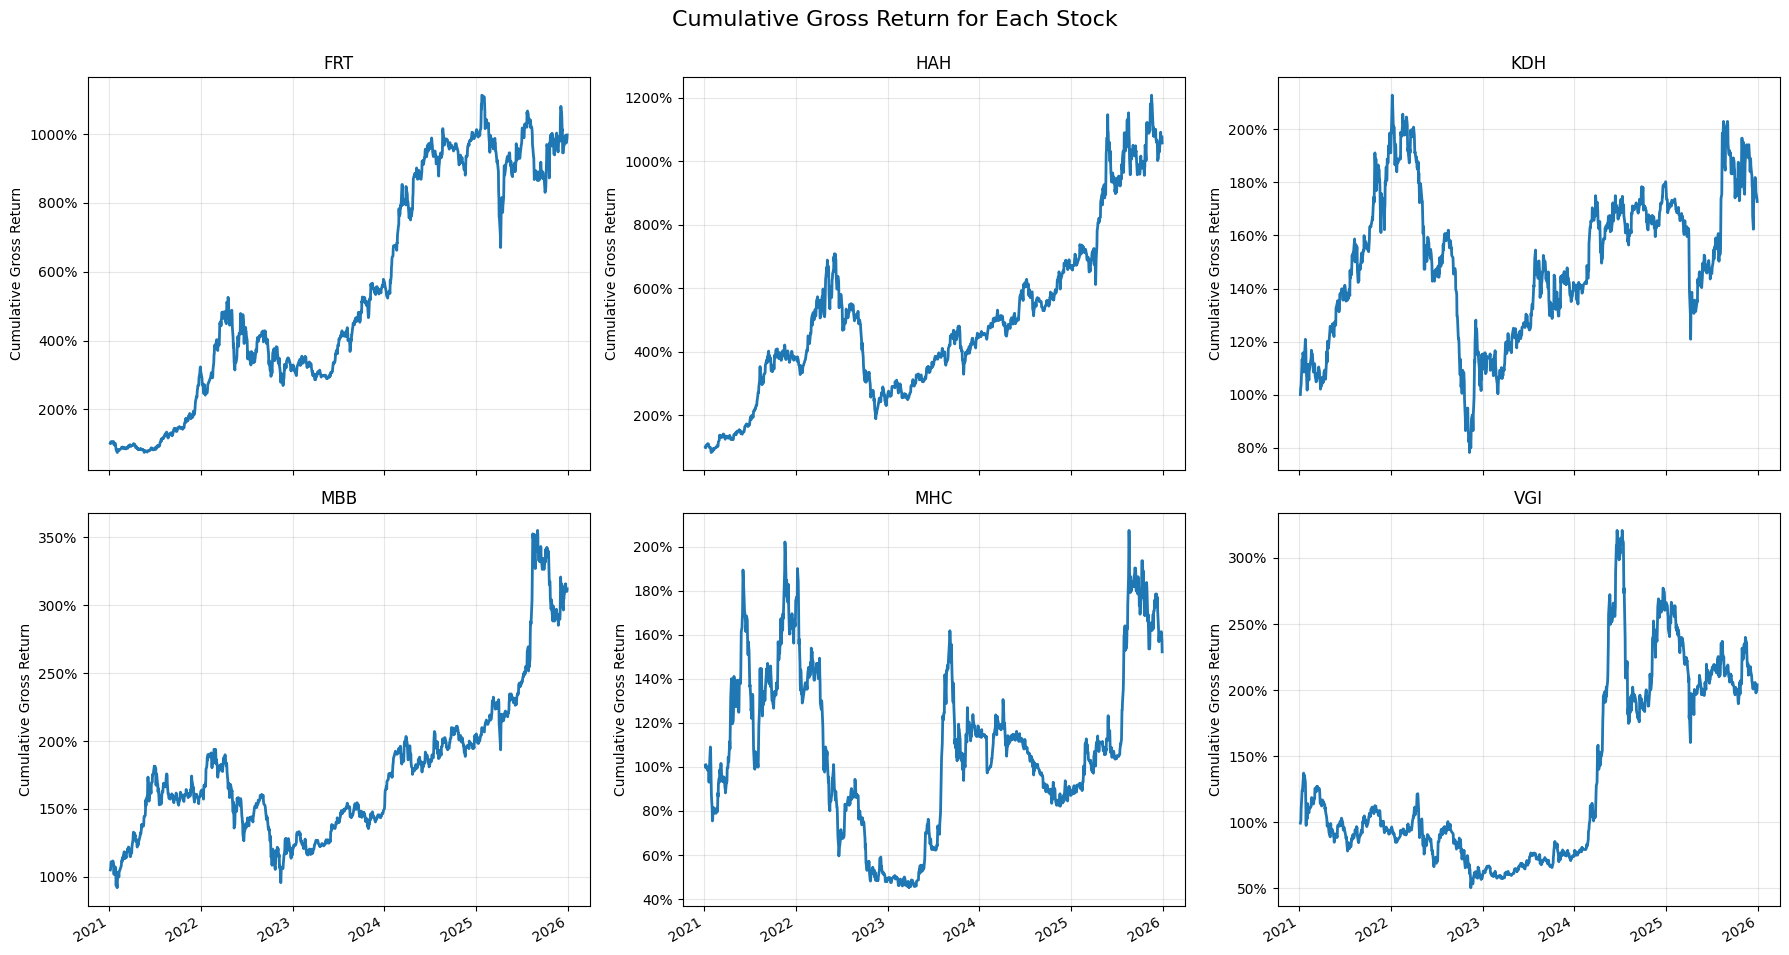

In [78]:


# Vẽ biểu đồ cumulative gross cho từng cổ phiếu trong một bảng lớn

df_portfolio['gross_return'] = 1 + df_portfolio['ret_simple']
df_portfolio['cum_gross'] = df_portfolio.groupby(symbol_col)['gross_return'].cumprod()

symbols = sorted(df_portfolio[symbol_col].unique())
rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(18, 10), sharex=True)
axes = axes.flatten()

for i, symbol in enumerate(symbols):
    group = df_portfolio[df_portfolio[symbol_col] == symbol]
    axes[i].plot(group['Date'], group['cum_gross'], label=f'{symbol} cum gross', linewidth=2)
    axes[i].set_title(symbol)
    axes[i].set_ylabel('Cumulative Gross Return')
    axes[i].grid(alpha=0.3)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for j in range(len(symbols), len(axes)):
    fig.delaxes(axes[j])

fig.autofmt_xdate(rotation=30)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
fig.suptitle('Cumulative Gross Return for Each Stock', fontsize=16)
plt.show()

In [79]:
# Factor modeling: build market factor, align returns, run OLS per stock
import os
import statsmodels.api as sm

# Build/locate market series (weekly)
market_series = None
vn_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/VNINDEX.csv'
if os.path.exists(vn_path):
    VN = pd.read_csv(vn_path, index_col=0, parse_dates=True)
    vn_col = VN.columns[0]
    market_series = VN[vn_col].resample('W-FRI').last()
else:
    # check if VNINDEX present as a symbol in raw data
    if 'VNINDEX' in df_week2[symbol_col].unique():
        vn_df = df_week2[df_week2[symbol_col] == 'VNINDEX'].copy()
        vn_df['Date'] = pd.to_datetime(vn_df['Date'])
        market_series = vn_df.set_index('Date')['Close'].resample('W-FRI').last()
    else:
        # fallback: use average of available instrument weekly close as proxy
        market_series = data_weekly.mean(axis=1)

# Compute market weekly returns
market_weekly = market_series.pct_change()

# Weekly risk-free: prefer TBill if available
if 'TBill' in globals() and TBill is not None and 'rf_weekly' in TBill.columns:
    rf_weekly = TBill['rf_weekly'].resample('W-FRI').last().reindex(weekly_ret.index).fillna(method='ffill')
else:
    # approximate from annual R_f_annual
    R_f_annual = globals().get('R_f_annual', 0.05)
    rf_weekly = pd.Series((1 + R_f_annual) ** (1 / 52) - 1, index=weekly_ret.index)

# Build factor dataframe
df_factors = pd.DataFrame(index=weekly_ret.index)
df_factors['Market'] = market_weekly.reindex(df_factors.index)
df_factors['Market_Minus_Rf'] = df_factors['Market'] - rf_weekly

# Try to load SMB/HML if provided
ff_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao/output/FF_factors.csv'
if os.path.exists(ff_path):
    ff = pd.read_csv(ff_path, index_col=0, parse_dates=True)
    # Expect columns like SMB, HML, and maybe Market
    for c in ['SMB', 'HML']:
        if c in ff.columns:
            df_factors[c] = ff[c].reindex(df_factors.index)

print('Factors ready:')
print(df_factors.dropna().head())

# Run OLS per stock using excess returns (Ri - Rf)
results = {}
rows = []
for symbol in weekly_ret.columns:
    Y = weekly_ret[symbol].reindex(df_factors.index) - rf_weekly
    X_cols = ['Market_Minus_Rf']
    if 'SMB' in df_factors.columns:
        X_cols += ['SMB']
    if 'HML' in df_factors.columns:
        X_cols += ['HML']
    X = df_factors[X_cols].reindex(df_factors.index)
    X = sm.add_constant(X)
    mask = Y.notna() & X.notna().all(axis=1)
    if mask.sum() < 10:
        print(symbol, 'not enough observations for regression (n=', mask.sum(), ')')
        continue
    model = sm.OLS(Y[mask], X[mask]).fit()
    results[symbol] = model
    rows.append({
        'symbol': symbol,
        'alpha': model.params.get('const', np.nan),
        'beta_market': model.params.get('Market_Minus_Rf', np.nan),
        'R2': model.rsquared,
        'nobs': int(model.nobs)
    })

results_df = pd.DataFrame(rows).set_index('symbol')
print('\nRegression summary (key stats):')
print(results_df)

# Save detailed summaries if needed
model_summaries = {s: results[s].summary() for s in results}

Factors ready:
              Market  Market_Minus_Rf
Date                                 
2021-01-15  0.093968         0.093030
2021-01-22  0.005804         0.004865
2021-01-29 -0.149067        -0.150006
2021-02-05  0.022604         0.021665
2021-02-12 -0.016910        -0.017849

Regression summary (key stats):
           alpha  beta_market        R2  nobs
symbol                                       
FRT     0.003963     1.190441  0.630265   256
HAH     0.005215     0.851110  0.322270   256
KDH    -0.001675     0.752649  0.439058   256
MBB     0.001595     0.493432  0.221108   256
MHC     0.000287     0.700956  0.135224   256
VGI    -0.001715     1.090560  0.459228   256


In [80]:
# 3. Penalty methods: Ridge (L2) and Lasso (L1) with cross-validation
try:
    from sklearn.linear_model import RidgeCV, LassoCV
    from sklearn.preprocessing import StandardScaler
    from sklearn.pipeline import make_pipeline
except Exception as e:
    print('scikit-learn not available. Install with: pip install scikit-learn')
    raise

ridge_results = []
lasso_results = []
ridge_models = {}
lasso_models = {}

# Prepare factor matrix
X_full = df_factors.copy()
X_cols = [c for c in X_full.columns if c != 'Market']  # keep Market_Minus_Rf etc.
X_full = X_full[X_cols]

for symbol in weekly_ret.columns:
    y = weekly_ret[symbol].reindex(X_full.index) - rf_weekly
    X = X_full.reindex(y.index)
    mask = y.notna() & X.notna().all(axis=1)
    if mask.sum() < 10:
        print(symbol, 'skipped (insufficient data)')
        continue

    X_tr = X[mask]
    y_tr = y[mask]

    # Ridge with built-in CV over alphas
    alphas = [0.01, 0.1, 1.0, 10.0, 100.0]
    ridge = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
    ridge.fit(X_tr, y_tr)
    ridge_coef = ridge.named_steps['ridgecv'].coef_
    ridge_alpha = ridge.named_steps['ridgecv'].alpha_
    ridge_score = ridge.score(X_tr, y_tr)
    ridge_results.append({'symbol': symbol, 'alpha': ridge_alpha, 'R2': ridge_score, 'nobs': int(mask.sum())})
    ridge_models[symbol] = {'model': ridge, 'coef': ridge_coef, 'features': X_tr.columns.tolist()}

    # Lasso with CV
    lasso = make_pipeline(StandardScaler(), LassoCV(alphas=None, cv=5, max_iter=5000))
    lasso.fit(X_tr, y_tr)
    lasso_coef = lasso.named_steps['lassocv'].coef_
    lasso_alpha = lasso.named_steps['lassocv'].alpha_
    lasso_score = lasso.score(X_tr, y_tr)
    n_nonzero = (lasso_coef != 0).sum()
    lasso_results.append({'symbol': symbol, 'alpha': lasso_alpha, 'R2': lasso_score, 'n_nonzero': int(n_nonzero), 'nobs': int(mask.sum())})
    lasso_models[symbol] = {'model': lasso, 'coef': lasso_coef, 'features': X_tr.columns.tolist()}

ridge_df = pd.DataFrame(ridge_results).set_index('symbol') if ridge_results else pd.DataFrame()
lasso_df = pd.DataFrame(lasso_results).set_index('symbol') if lasso_results else pd.DataFrame()

print('\nRidge summary:')
print(ridge_df)
print('\nLasso summary:')
print(lasso_df)

# Show selected (non-zero) factors per stock for Lasso
print('\nLasso selected factors (non-zero coefficients):')
for s, info in lasso_models.items():
    coefs = info['coef']
    feats = info['features']
    selected = [f for f, c in zip(feats, coefs) if abs(c) > 1e-8]
    print(s + ':', selected)


Ridge summary:
        alpha        R2  nobs
symbol                       
FRT      10.0  0.629374   256
HAH      10.0  0.321814   256
KDH      10.0  0.438437   256
MBB      10.0  0.220796   256
MHC     100.0  0.124554   256
VGI     100.0  0.422993   256

Lasso summary:
           alpha        R2  n_nonzero  nobs
symbol                                     
FRT     0.000051  0.630264          1   256
HAH     0.000036  0.322269          1   256
KDH     0.000032  0.439057          1   256
MBB     0.000021  0.221108          1   256
MHC     0.000030  0.135224          1   256
VGI     0.006136  0.451202          1   256

Lasso selected factors (non-zero coefficients):
FRT: ['Market_Minus_Rf']
HAH: ['Market_Minus_Rf']
KDH: ['Market_Minus_Rf']
MBB: ['Market_Minus_Rf']
MHC: ['Market_Minus_Rf']
VGI: ['Market_Minus_Rf']


In [81]:
from sklearn.model_selection import KFold
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error

class PurgedGroupTimeSeriesSplit:
    """
    Purged and Embargoed Time Series Split cho Dữ liệu Tài chính
    """
    def __init__(self, n_splits=5, purge_pct=0.02, embargo_pct=0.01):
        self.n_splits = n_splits
        self.purge_pct = purge_pct      # Tỷ lệ loại bỏ điểm chồng lấn
        self.embargo_pct = embargo_pct  # Tỷ lệ cấm vận phía sau Validation

    def split(self, X, y=None, groups=None):
        n_samples = len(X)
        k_fold = KFold(n_splits=self.n_splits, shuffle=False)
        
        # Tính toán số lượng mẫu cho bộ đệm
        purge_size = int(n_samples * self.purge_pct)
        embargo_size = int(n_samples * self.embargo_pct)
        
        for train_indices, test_indices in k_fold.split(X):
            # Biên của tập Validation (Test)
            test_start = test_indices[0]
            test_end = test_indices[-1]
            
            # Tiến hành Purging tập Train nằm TRƯỚC tập Test nếu có chồng lấn
            purged_train_indices = [i for i in train_indices if i < test_start or i > test_end]
            
            # Tiến hành Embargo tập Train nằm NGAY SAU tập Test
            embargo_limit = test_end + embargo_size + purge_size
            final_train_indices = [i for i in purged_train_indices if i < test_start or i > embargo_limit]
            
            if len(final_train_indices) > 0:
                yield np.array(final_train_indices), np.array(test_indices)

# --- ÁP DỤNG PURGED CV ĐỂ TÌM LAMBDA (ALPHA) TỐI ƯU CHO RIDGE ---

ridge_purged_results = []
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

print("--- BẮT ĐẦU HUẤN LUYỆN VỚI PURGED K-FOLD CV (N_SPLITS=5) ---")

for symbol in weekly_ret.columns:
    y = weekly_ret[symbol].reindex(X_full.index) - rf_weekly
    X = X_full.reindex(y.index)
    mask = y.notna() & X.notna().all(axis=1)
    
    if mask.sum() < 30: # Cần đủ số lượng mẫu để chia K-fold
        continue
        
    X_clean = X[mask].reset_index(drop=True)
    y_clean = y[mask].reset_index(drop=True)
    
    # Khởi tạo bộ chia dữ liệu chống rò rỉ
    cv_purged = PurgedGroupTimeSeriesSplit(n_splits=5, purge_pct=0.02, embargo_pct=0.02)
    
    best_alpha = None
    best_score = float('inf')
    
    # Vòng lặp tối ưu hóa siêu tham số (Hyperparameter Tuning) thủ công qua Purged CV
    for alpha in alphas:
        cv_scores = []
        for train_idx, val_idx in cv_purged.split(X_clean):
            X_train, y_train = X_clean.iloc[train_idx], y_clean.iloc[train_idx]
            X_val, y_val = X_clean.iloc[val_idx], y_clean.iloc[val_idx]
            
            # Chuẩn hóa dữ liệu độc lập trên từng Fold để tránh rò rỉ quy mô
            scaler = StandardScaler()
            X_train_scaled = scaler.fit_transform(X_train)
            X_val_scaled = scaler.transform(X_val)
            
            # Fit mô hình
            model = Ridge(alpha=alpha)
            model.fit(X_train_scaled, y_train)
            
            # Dự báo và tính toán sai số (MSE) trên tập Validation sạch
            preds = model.predict(X_val_scaled)
            cv_scores.append(mean_squared_error(y_val, preds))
            
        avg_score = np.mean(cv_scores) if cv_scores else float('inf')
        if avg_score < best_score:
            best_score = avg_score
            best_alpha = alpha
            
    # Huấn luyện lại mô hình cuối cùng với Alpha tối ưu trên TOÀN BỘ dữ liệu của mã đó
    scaler_full = StandardScaler()
    X_full_scaled = scaler_full.fit_transform(X_clean)
    final_model = Ridge(alpha=best_alpha)
    final_model.fit(X_full_scaled, y_clean)
    
    ridge_purged_results.append({
        'symbol': symbol,
        'best_lambda_α': best_alpha,
        'val_mse': best_score,
        'final_R2': final_model.score(X_full_scaled, y_clean)
    })

df_purged_summary = pd.DataFrame(ridge_purged_results).set_index('symbol')
print('\nKết quả mô hình sau khi sửa lỗi rò rỉ dữ liệu (Purged Ridge):')
print(df_purged_summary)

--- BẮT ĐẦU HUẤN LUYỆN VỚI PURGED K-FOLD CV (N_SPLITS=5) ---

Kết quả mô hình sau khi sửa lỗi rò rỉ dữ liệu (Purged Ridge):
        best_lambda_α   val_mse  final_R2
symbol                                   
FRT              0.01  0.001579  0.630265
HAH              0.01  0.002853  0.322270
KDH              0.01  0.001335  0.439058
MBB              1.00  0.001631  0.221105
MHC              1.00  0.006011  0.135222
VGI             10.00  0.002966  0.458578


In [82]:
import scipy.cluster.hierarchy as sch

# --- BƯỚC 1: TÍNH MA TRẬN TƯƠNG QUAN VÀ KHOẢNG CÁCH ---
cov_matrix = weekly_ret.cov().fillna(0.0)
corr_matrix = weekly_ret.corr().fillna(0.0)

# Tính khoảng cách d_ij = sqrt(0.5 * (1 - rho_ij))
distance_matrix = np.sqrt(0.5 * (1 - corr_matrix))

# --- BƯỚC 2: PHÂN CỤM SƠ ĐỒ CÂY & SẮP XẾP LẠI (QUASI-DIAGONALIZATION) ---
linkage_matrix = sch.linkage(sch.distance.squareform(distance_matrix), method='single')

# GIẢI PHÁP THAY THẾ: Sử dụng leaves_list() của scipy cực kỳ an toàn và nhanh gọn
ordered_indices = sch.leaves_list(linkage_matrix)
ordered_symbols = [corr_matrix.columns[i] for i in ordered_indices]


# --- BƯỚC 3: PHÂN BỔ VỐN ĐỆ QUY (RECURSIVE BISECTION) ---
def get_cluster_var(cov, cluster_items):
    cov_slice = cov.loc[cluster_items, cluster_items]
    weights_inv = 1.0 / np.diag(cov_slice)
    weights_inv /= weights_inv.sum()
    cluster_var = np.dot(weights_inv.T, np.dot(cov_slice, weights_inv))
    return cluster_var

def get_hrp_weights(cov, ordered_symbols):
    weights = pd.Series(1.0, index=ordered_symbols)
    items = [ordered_symbols]
    
    while len(items) > 0:
        items = [i[j:k] for i in items for j, k in ((0, len(i) // 2), (len(i) // 2, len(i))) if len(i) > 1]
        
        for i in range(0, len(items), 2):
            cluster_1 = items[i]     # Cụm trái
            cluster_2 = items[i+1]   # Cụm phải
            
            var_1 = get_cluster_var(cov, cluster_1)
            var_2 = get_cluster_var(cov, cluster_2)
            
            alpha = 1.0 - var_1 / (var_1 + var_2)
            
            weights[cluster_1] *= alpha
            weights[cluster_2] *= (1.0 - alpha)
            
    return weights

# Tính toán tỷ trọng HRP
hrp_weights_series = get_hrp_weights(cov_matrix, ordered_symbols)


# --- BƯỚC 4: TỔNG HỢP VÀ SO SÁNH VỚI MARKOWITZ ---
df_allocation = pd.DataFrame(index=selected_symbols)

if 'df_weights' in globals() and not df_weights.empty:
    df_allocation['Markowitz_MaxSharpe'] = df_weights['Max_Sharpe_Weight']
    df_allocation['Markowitz_MinVar'] = df_weights['Min_Variance_Weight']
else:
    df_allocation['Markowitz_MaxSharpe'] = np.nan
    df_allocation['Markowitz_MinVar'] = np.nan

df_allocation['HRP_Weight'] = hrp_weights_series.reindex(df_allocation.index)

print("--- SO SÁNH TỶ TRỌNG VỐN CHUẨN: MARKOWITZ VS HRP ---")
display(df_allocation.round(4) * 100)

--- SO SÁNH TỶ TRỌNG VỐN CHUẨN: MARKOWITZ VS HRP ---


,Markowitz_MaxSharpe,Markowitz_MinVar,HRP_Weight
MHC,NaN,NaN,11.38
MBB,NaN,NaN,23.83
FRT,NaN,NaN,17.29
HAH,NaN,NaN,14.54
VGI,NaN,NaN,12.62
KDH,NaN,NaN,20.34


In [83]:
import scipy.stats as ss

# --- BƯỚC 1: TÍNH TOÁN CHUỖI LỢI NHUẬN TUẦN CỦA CÁC CHIẾN LƯỢC ---
weekly_ret_filled = weekly_ret.fillna(0.0)

# 1. Lợi nhuận tuần của Markowitz Max Sharpe
w_sharpe = df_allocation['Markowitz_MaxSharpe'].fillna(0.0).values
port_max_sharpe_ret = weekly_ret_filled.dot(w_sharpe)

# 2. Lợi nhuận tuần của HRP
w_hrp = df_allocation['HRP_Weight'].fillna(0.0).values
port_hrp_ret = weekly_ret_filled.dot(w_hrp)

# 3. Lợi nhuận tuần của Thị trường (VNINDEX)
market_ret_series = market_weekly.reindex(weekly_ret_filled.index).fillna(0.0)

# Lấy lãi suất phi rủi ro tuần (hằng số) để tính toán
R_f_annual = globals().get('R_f_annual', 0.05)
rf_weekly_const = (1 + R_f_annual) ** (1 / 52) - 1


# --- BƯỚC 2: HÀM TÍNH TOÁN TOÀN BỘ CHỈ SỐ BACKTEST NÂN CAO ---
def calc_backtest_statistics(returns, rf_weekly, benchmark_sr=0.0):
    """
    Tính toán Sharpe Ratio, Maximum Drawdown và Probabilistic Sharpe Ratio (PSR)
    """
    nobs = len(returns)
    if nobs < 2:
        return {}
    
    # 1. Tính toán Tỷ suất sinh lời và Biến động (Tuần & Quy năm)
    mean_ret = returns.mean()
    std_ret = returns.std()
    
    # Sharpe Ratio tuần và Sharpe Ratio quy năm (đã trừ Rf)
    excess_ret = mean_ret - rf_weekly
    sharpe_weekly = excess_ret / std_ret if std_ret != 0 else 0
    sharpe_annualized = sharpe_weekly * np.sqrt(52)
    
    # 2. Tính toán Maximum Drawdown (MDD)
    cum_gross = (1 + returns).cumprod()
    running_max = cum_gross.cummax()
    drawdowns = (cum_gross - running_max) / running_max
    max_dd = drawdowns.min()
    
    # 3. Tính toán Probabilistic Sharpe Ratio (PSR)
    # Cần Skewness (độ lệch) và Kurtosis (độ nhọn) để hiệu chỉnh phân phối phi chuẩn
    skew = ss.skew(returns)
    kurt = ss.kurtosis(returns) # Excess kurtosis
    
    # Công thức tính sai số chuẩn của Sharpe Ratio (tính theo dạng tuần)
    # Hệ số hiệu chỉnh cho các phân phối có đuôi dày (Fat-tailed)
    sr_variance = (1.0 + 0.5 * sharpe_weekly**2 - skew * sharpe_weekly + (kurt / 4.0) * sharpe_weekly**2) / (nobs - 1)
    sr_std_err = np.sqrt(sr_variance)
    
    # Tính giá trị Z-score so với một mức Sharpe mục tiêu (benchmark_sr, thường để = 0 để chứng minh chiến lược có kỹ năng)
    benchmark_sr_weekly = benchmark_sr / np.sqrt(52)
    z_stat = (sharpe_weekly - benchmark_sr_weekly) / sr_std_err if sr_std_err != 0 else 0
    
    # Đổi từ Z-score sang xác suất tích lũy (CDF)
    psr = ss.norm.cdf(z_stat)
    
    return {
        'Annualized Return': mean_ret * 52,
        'Annualized Volatility': std_ret * np.sqrt(52),
        'Annualized Sharpe': sharpe_annualized,
        'Maximum Drawdown': max_dd,
        'Probabilistic Sharpe (PSR)': psr,
        'Observations (Weeks)': nobs
    }

# --- BƯỚC 3: CHẠY ĐÁNH GIÁ CHO CÁC CHIẾN LƯỢC ---
stats_max_sharpe = calc_backtest_statistics(port_max_sharpe_ret, rf_weekly_const)
stats_hrp = calc_backtest_statistics(port_hrp_ret, rf_weekly_const)
stats_market = calc_backtest_statistics(market_ret_series, rf_weekly_const)

# Tổng hợp vào một DataFrame số thô
df_stats = pd.DataFrame({
    'Markowitz_MaxSharpe': stats_max_sharpe,
    'HRP_Portfolio': stats_hrp,
    'VNINDEX_Market': stats_market
})

print("--- BẢNG THỐNG KÊ HIỆU QUẢ DANH MỤC NÂNG CAO ---")

# GIẢI PHÁP SỬA LỖI: Ép kiểu toàn bộ bảng sang Object/String trước khi định dạng chuỗi
df_formatting = df_stats.astype(object)

for col in df_formatting.columns:
    df_formatting.loc['Annualized Return', col] = f"{df_stats.loc['Annualized Return', col]*100:.2f}%"
    df_formatting.loc['Annualized Volatility', col] = f"{df_stats.loc['Annualized Volatility', col]*100:.2f}%"
    df_formatting.loc['Annualized Sharpe', col] = f"{df_stats.loc['Annualized Sharpe', col]:.3f}"
    df_formatting.loc['Maximum Drawdown', col] = f"{df_stats.loc['Maximum Drawdown', col]*100:.2f}%"
    df_formatting.loc['Probabilistic Sharpe (PSR)', col] = f"{df_stats.loc['Probabilistic Sharpe (PSR)', col]*100:.2f}%"
    df_formatting.loc['Observations (Weeks)', col] = f"{int(df_stats.loc['Observations (Weeks)', col])}"

display(df_formatting)

--- BẢNG THỐNG KÊ HIỆU QUẢ DANH MỤC NÂNG CAO ---


,Markowitz_MaxSharpe,HRP_Portfolio,VNINDEX_Market
Annualized Return,0.00%,32.74%,29.71%
Annualized Volatility,0.00%,28.27%,30.46%
Annualized Sharpe,0.000,0.985,0.815
Maximum Drawdown,0.00%,-51.53%,-50.17%
Probabilistic Sharpe (PSR),nan%,98.17%,96.12%
Observations (Weeks),261,261,261


In [84]:
# Kiểm tra sự tồn tại của file hàm bổ trợ trước khi import
import sys
import os

# Đảm bảo đường dẫn thư mục chứa file chức năng được Python nhận diện
folder_path = '/workspaces/Phan-Tich-va-Quan-Li-Dau-Tu-Nang-Cao'
if folder_path not in sys.path:
    sys.path.append(folder_path)

try:
    # Import hàm vẽ đồ thị từ file chức năng của bạn
    # (Tên hàm có thể thay đổi tùy thuộc vào cấu trúc chính xác bên trong file .py của bạn)
    from Graphical_Analysis_functions import run_graphical_analysis
    
    print("Sẵn sàng chạy phân tích cấu trúc đồ thị thị trường...")
    
    # Chuẩn bị dữ liệu đầu vào: Loại bỏ NaN để thuật toán ML không bị lỗi
    X_graph = weekly_ret.dropna()
    
    # Thực hiện thuật toán vẽ đồ thị 
    # Hàm này sẽ tự động chạy Graphical Lasso, Affinity Propagation, MDS và hiển thị biểu đồ 2D
    run_graphical_analysis(X_graph)
    
except ImportError:
    print("CẢNH BÁO: Không tìm thấy file 'Graphical_Analysis_functions.py' tại đường dẫn chỉ định.")
    print("Vui lòng đảm bảo file đã được đặt trong thư mục làm việc của bạn.")
except Exception as e:
    print(f"Có lỗi xảy ra trong quá trình xử lý đồ thị: {e}")

CẢNH BÁO: Không tìm thấy file 'Graphical_Analysis_functions.py' tại đường dẫn chỉ định.
Vui lòng đảm bảo file đã được đặt trong thư mục làm việc của bạn.


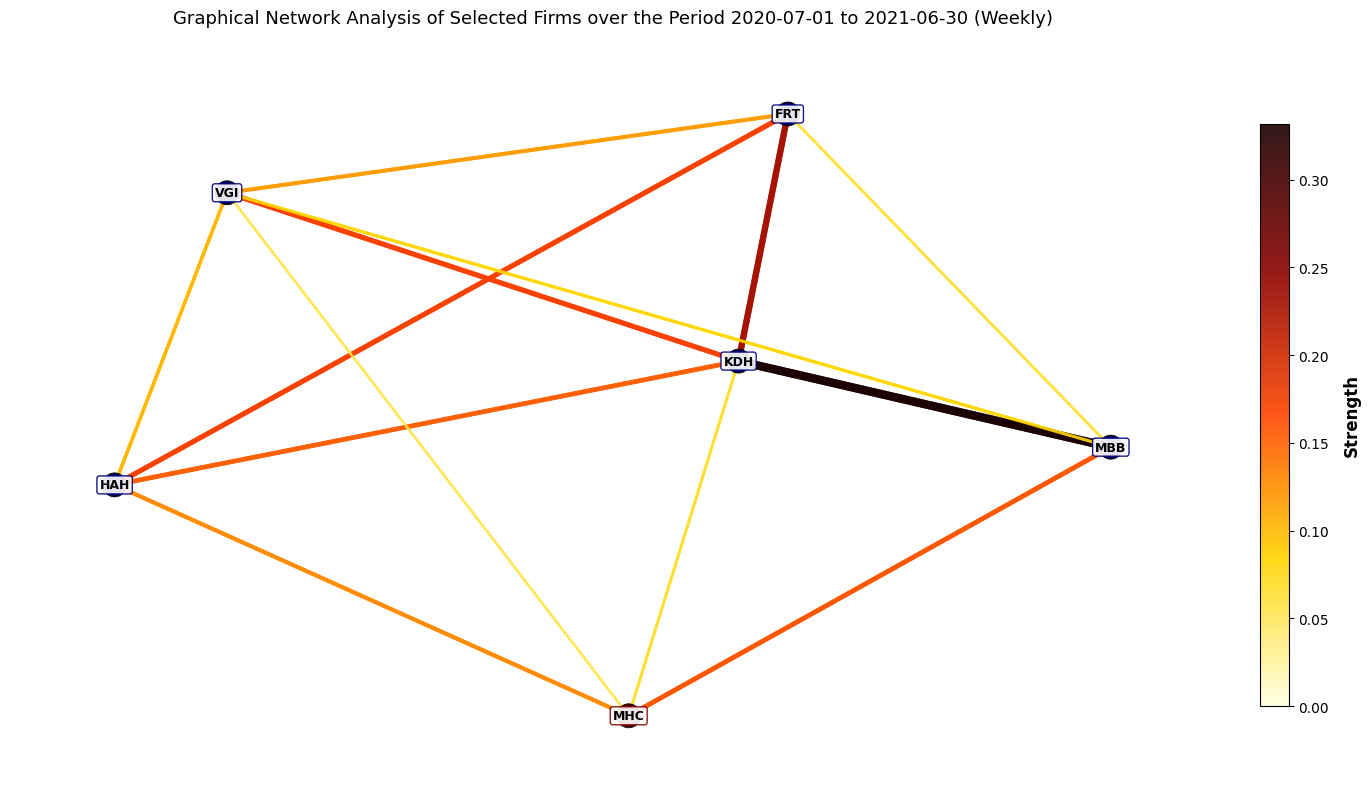

In [85]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np
import pandas as pd

# --- BƯỚC 1: KHỞI TẠO ĐỒ THỊ VÀ THÊM THÔNG TIN NÚT ---
plt.figure(figsize=(15, 8))
G = nx.Graph()

# Định nghĩa bảng màu thủ công dựa trên cấu trúc các cụm phân loại trong hình của bạn:
# Xanh dương đậm (Banks), Cam (Tech), Xanh lá (Energy/Retail), Xanh dương nhạt (Healthcare)
# Để đồng bộ, chúng ta lấy nhãn cụm (cluster_labels) từ mô hình Affinity Propagation của bạn
unique_labels = np.unique(cluster_labels)
num_clusters = len(unique_labels)

# Sử dụng bảng màu mdi (Jet hoặc Rainbow tương tự ảnh mẫu)
cmap_nodes = cm.get_cmap('jet', num_clusters) if hasattr(cm, 'get_cmap') else bcm.colormaps['jet'].resampled(num_clusters)
node_color_map = {label: cmap_nodes(i) for i, label in enumerate(unique_labels)}

# Thêm nút kèm tọa độ MDS và màu sắc tương ứng
for i, symbol in enumerate(symbols):
    G.add_node(symbol, 
               pos=(node_positions[i, 0], node_positions[i, 1]), 
               color=node_color_map[cluster_labels[i]],
               cluster_id=cluster_labels[i])

# --- BƯỚC 2: THÊM CẠNH VÀ THIẾT LẬP TRỌNG SỐ ---
# Sử dụng ma trận cond_corr thu được từ Graphical Lasso
for i in range(len(symbols)):
    for j in range(i + 1, len(symbols)):
        weight = cond_corr[i, j]
        # Giữ lại các mối quan hệ dương (hoặc trị tuyệt đối nếu bạn muốn tính cả tương quan nghịch)
        if weight > 0.0:  
            G.add_edge(symbols[i], symbols[j], weight=weight)

# --- BƯỚC 3: CẤU HÌNH ĐỒ HỌA MÀU SẮC CHO CẠNH (EDGE COLORBAR) ---
pos = nx.get_node_attributes(G, 'pos')
edges = G.edges(data=True)

# Trích xuất trọng số của các cạnh
edge_weights = [e[2]['weight'] for e in edges]

# Sử dụng bảng màu 'hot_r' hoặc một Colormap tùy chỉnh chuyển từ Vàng -> Đỏ -> Đen (giống ảnh mẫu)
# Ở đây 'hot_r' hoặc tạo mcolors.LinearSegmentedColormap là chuẩn nhất với dải màu trong ảnh của bạn.
colors_list = ["#FFFFE0", "#FFD700", "#FF4500", "#8B0000", "#1A0000"] # Vàng nhạt -> Vàng -> Cam -> Đỏ -> Đen
custom_edge_cmap = mcolors.LinearSegmentedColormap.from_list("custom_financial", colors_list)

# Chuẩn hóa dải màu cho cạnh từ mốc 0.00 đến tối đa (ví dụ 0.35)
v_min, v_max = 0.0, max(edge_weights) if len(edge_weights) > 0 else 0.35
norm = mcolors.Normalize(vmin=v_min, vmax=v_max)
edge_colors = [custom_edge_cmap(norm(w)) for w in edge_weights]

# Độ dày của nét vẽ tỷ lệ thuận với cường độ tương quan điều kiện
edge_widths = [1 + (w / v_max) * 5 for w in edge_weights] if len(edge_weights) > 0 else [1]*len(edges)

# --- BƯỚC 4: TIẾN HÀNH VẼ ĐỒ THỊ ---
# 1. Vẽ các cạnh nối (Edges) trước để nút đè lên trên cho đẹp
nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color=edge_colors, width=edge_widths, alpha=0.9)

# 2. Vẽ các nút (Nodes)
node_colors_list = [G.nodes[node]['color'] for node in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=node_colors_list, node_size=300, edgecolors='black', linewidths=0.5)

# 3. Vẽ nhãn văn bản (Labels) nằm trong khung hình hộp chữ nhật màu trắng
for node, (x, y) in pos.items():
    # Lấy màu viền hộp trùng với màu phân cụm của nút để đồng bộ giống hệt ảnh mẫu
    c_id = G.nodes[node]['cluster_id']

    # --- BƯỚC 4: TIẾN HÀNH VẼ ĐỒ THỊ CHUẨN XÁC ---
# 1. Vẽ các cạnh nối và hứng đối tượng đồ họa (collection) để làm gốc dựng Colorbar
edge_collection = nx.draw_networkx_edges(
    G, pos, 
    edgelist=edges, 
    edge_color=edge_weights,       # Truyền mảng số thô vào đây
    edge_cmap=custom_edge_cmap,    # Áp bảng màu tùy chỉnh tại đây
    edge_vmin=v_min, 
    edge_vmax=v_max, 
    width=edge_widths, 
    alpha=0.9
)

# 2. Vẽ các nút (Nodes) hình tròn phía dưới nhãn
node_colors_list = [G.nodes[node]['color'] for node in G.nodes]
nx.draw_networkx_nodes(G, pos, node_color=node_colors_list, node_size=250, edgecolors='black', linewidths=0.5)

# 3. Vẽ nhãn văn bản (Labels) nằm trong khung hình hộp chữ nhật màu trắng
for node, (x, y) in pos.items():
    c_id = G.nodes[node]['cluster_id']
    box_color = node_color_map[c_id]
    
    plt.text(
        x, y, s=node, 
        bbox=dict(facecolor='white', edgecolor=box_color, boxstyle='round,pad=0.2', alpha=0.9),
        horizontalalignment='center', verticalalignment='center', 
        fontsize=9, fontname='sans-serif', fontweight='semibold'
    )


# --- BƯỚC 5: HIỂN THỊ CỘT ĐO MÀU BÊN PHẢI (COLORBAR) VÀ TIÊU ĐỀ ---
# Khởi tạo thanh Colorbar liên kết trực tiếp với các cạnh vừa vẽ
cbar = plt.colorbar(edge_collection, ax=plt.gca(), orientation='vertical', shrink=0.8, pad=0.03)
cbar.set_label('Strength', fontsize=12, fontweight='bold', labelpad=10)

# Định dạng các điểm mốc trên Colorbar hiển thị dạng số thập phân chuẩn (0.00, 0.05, ...)
cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))

# Lấy thông số thời gian động điền vào tiêu đề giống ảnh mẫu
s_d = globals().get('start_date', '12/30/2019')
e_d = globals().get('end_date', '06/28/2020')
plt.title(f'Graphical Network Analysis of Selected Firms over the Period {s_d} to {e_d} (Weekly)', 
          fontsize=13, fontweight='regular', pad=20)

# Tối ưu khoảng trống để không bị đè chữ lên cột bên phải
plt.axis('off')
plt.tight_layout()
plt.show()

--- ĐÃ LỌC DỮ LIỆU THÀNH CÔNG ---
Khoảng thời gian: 2023-01-01 đến 2025-12-31
Danh sách cổ phiếu tham gia phân tích mạng lưới (6 mã): ['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']

--- 📊 BẢNG THỐNG KÊ MÔ TẢ HIỆU SUẤT ĐẦU TƯ (SUMMARY STATISTICS) ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
symbol,,,,,,,,,,
FRT,747.0,0.00172,0.02011,-0.07000,-0.00929,0.00000,0.01116,0.06966,0.46757,2.29070
HAH,747.0,0.00220,0.02420,-0.07017,-0.01131,0.00108,0.01479,0.06988,0.10083,1.38575
KDH,747.0,0.00081,0.01977,-0.07003,-0.00746,0.00000,0.00898,0.06985,0.09796,2.71509
MBB,747.0,0.00146,0.01588,-0.07002,-0.00667,0.00000,0.00838,0.06977,0.20111,3.86633
MHC,747.0,0.00192,0.02803,-0.07063,-0.01230,0.00000,0.01498,0.07046,0.23461,0.81530
VGI,746.0,0.00208,0.02789,-0.14495,-0.01148,0.00000,0.01418,0.14594,-0.03682,4.78362




--- 📈 ĐỒ THỊ TỶ SUẤT SINH LỜI GỘP TÍCH LŨY TỪNG CỔ PHIẾU ---


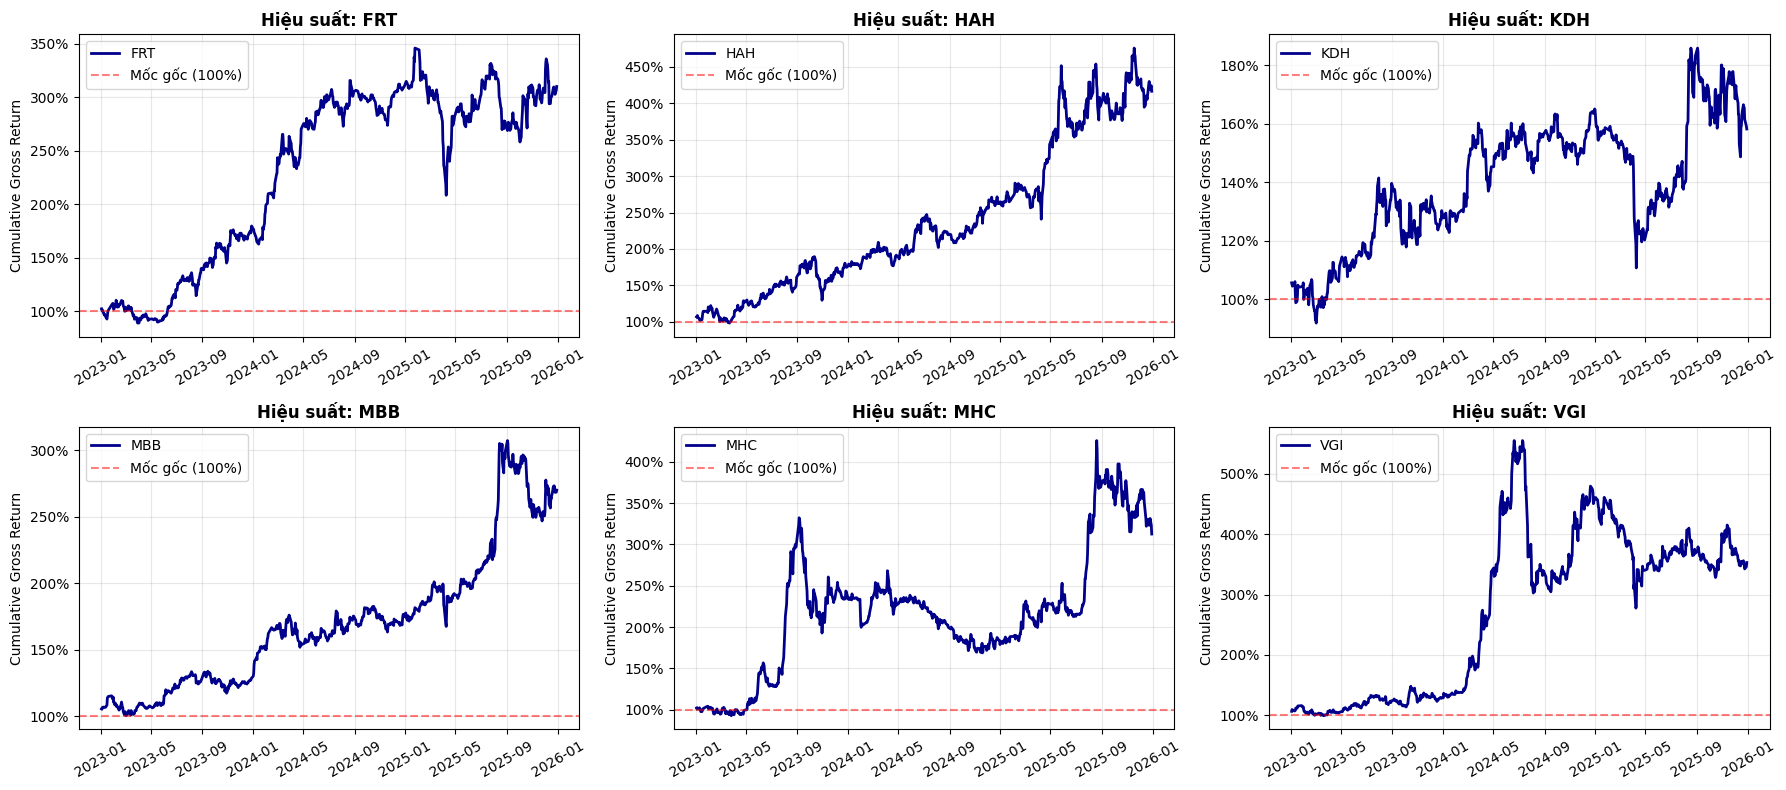

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ==============================================================================
# CONFIGURATION PANEL (Người dùng tùy chỉnh cấu hình tại đây)
# ==============================================================================
start_date = '2023-01-01'      # Định dạng: 'YYYY-MM-DD' (Để None nếu lấy từ đầu)
end_date = '2025-12-31'        # Định dạng: 'YYYY-MM-DD' (Để None nếu lấy đến cuối)

Sectors_chosen = []            # Ví dụ: ['Bank', 'Tech'] | [] nghĩa là lấy TẤT CẢ các ngành
drop_firm = []                 # Ví dụ: ['FRC', 'RY']    | [] nghĩa là KHÔNG loại bỏ mã nào

display_SumStat = True         # Hiển thị bảng Thống kê mô tả (Summary Statistics)
display_IndRet = True          # Hiển thị biểu đồ Hiệu suất tích lũy cá nhân từng mã
# ==============================================================================

# --- BƯỚC 1: KHỞI TẠO VÀ LỌC THEO THỜI GIAN ---
df_filtered = df_portfolio.copy()
df_filtered['Date'] = pd.to_datetime(df_filtered['Date'])

if start_date is not None:
    df_filtered = df_filtered[df_filtered['Date'] >= pd.to_datetime(start_date)]
if end_date is not None:
    df_filtered = df_filtered[df_filtered['Date'] <= pd.to_datetime(end_date)]

# --- BƯỚC 2: LỌC THEO NGÀNH (SECTORS CHOSEN) ---
# (Giả định df_portfolio của bạn có cột 'Sector' phân loại ngành cho từng cổ phiếu)
if Sectors_chosen and 'Sector' in df_filtered.columns:
    df_filtered = df_filtered[df_filtered['Sector'].isin(Sectors_chosen)]
elif Sectors_chosen and 'Sector' not in df_filtered.columns:
    print("CẢNH BÁO: Không tìm thấy cột 'Sector' trong dữ liệu. Tự động bao gồm tất cả các mã.")

# --- BƯỚC 3: LOẠI BỎ CỔ PHIẾU CHỈ ĐỊNH (DROP FIRM) ---
if drop_firm:
    # Loại bỏ các mã nằm trong danh sách drop_firm ở cột ký hiệu cổ phiếu (symbol_col)
    df_filtered = df_filtered[~df_filtered[symbol_col].isin(drop_firm)]

# Lấy danh sách các mã cổ phiếu còn lại sau khi lọc
active_symbols = sorted(df_filtered[symbol_col].unique())
print(f"--- ĐÃ LỌC DỮ LIỆU THÀNH CÔNG ---")
print(f"Khoảng thời gian: {start_date} đến {end_date}")
print(f"Danh sách cổ phiếu tham gia phân tích mạng lưới ({len(active_symbols)} mã): {active_symbols}\n")


# --- BƯỚC 4: HIỂN THỊ THỐNG KÊ MÔ TẢ (SUMMARY STATISTICS) ---
if display_SumStat:
    print("--- 📊 BẢNG THỐNG KÊ MÔ TẢ HIỆU SUẤT ĐẦU TƯ (SUMMARY STATISTICS) ---")
    # Tạo bảng pivot tỷ suất sinh lời ngày để tính thống kê
    df_pivot_ret = df_filtered.pivot(index='Date', columns=symbol_col, values='ret_simple')
    
    sum_stat = df_pivot_ret.describe().T
    # Tính thêm chỉ số Skewness (Độ lệch) và Kurtosis (Độ nhọn) phục vụ cho mô hình PSR phía sau
    sum_stat['skewness'] = df_pivot_ret.skew()
    sum_stat['kurtosis'] = df_pivot_ret.kurtosis()
    
    display(sum_stat.round(5))
    print("\n" + "="*80 + "\n")


# --- BƯỚC 5: HIỂN THỊ BIỂU ĐỒ HIỆU SUẤT TÍCH LŨY CÁ NHÂN (INDIVIDUAL PERFORMANCE) ---
if display_IndRet and len(active_symbols) > 0:
    print("--- 📈 ĐỒ THỊ TỶ SUẤT SINH LỜI GỘP TÍCH LŨY TỪNG CỔ PHIẾU ---")
    
    # Tính toán lại hiệu suất tích lũy bắt đầu từ ngày đầu tiên của khoảng thời gian lọc (fillna(0) như đã tối ưu ở Bước 1)
    df_filtered['gross_return'] = 1 + df_filtered['ret_simple'].fillna(0.0)
    df_filtered['cum_gross'] = df_filtered.groupby(symbol_col)['gross_return'].cumprod()
    
    # Cấu hình lưới đồ thị động dựa trên số lượng cổ phiếu thực tế còn lại
    num_plots = len(active_symbols)
    cols = min(3, num_plots)
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows), sharex=False)
    # Đảm bảo axes luôn là một mảng phẳng ngay cả khi chỉ có 1 hoặc nhiều hàng
    if num_plots == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten()
        
    for i, symbol in enumerate(active_symbols):
        group = df_filtered[df_filtered[symbol_col] == symbol].sort_values('Date')
        axes[i].plot(group['Date'], group['cum_gross'], label=f'{symbol}', linewidth=2, color='darkblue')
        axes[i].axhline(1.0, color='red', linestyle='--', alpha=0.5, label='Mốc gốc (100%)')
        axes[i].set_title(f"Hiệu suất: {symbol}", fontsize=12, fontweight='bold')
        axes[i].set_ylabel('Cumulative Gross Return')
        axes[i].grid(alpha=0.3)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axes[i].tick_params(axis='x', rotation=30)
        axes[i].legend(loc='upper left')
        
    # Xóa các khung đồ thị trống thừa nếu có
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])
        
    fig.tight_layout()
    plt.show()

======================= SECOND DATA ANALYSIS =======================
Thời gian phân tích: 2020-07-01 đến 2021-06-30
Số lượng cổ phiếu thỏa mãn bộ lọc: 6 mã
Danh sách mã: ['FRT', 'HAH', 'KDH', 'MBB', 'MHC', 'VGI']

--- 📊 BẢNG THỐNG KÊ MÔ TẢ GIAI ĐOẠN 2 ---


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
symbol,,,,,,,,,,
FRT,119.0,-0.00112,0.02699,-0.06984,-0.01255,0.00000,0.01330,0.06857,-0.09268,1.04886
HAH,119.0,0.00491,0.03038,-0.07049,-0.01499,0.00127,0.02361,0.07143,0.21316,0.08470
KDH,119.0,0.00313,0.02290,-0.06871,-0.01128,0.00130,0.01223,0.06982,0.06434,1.57859
MBB,119.0,0.00533,0.02592,-0.06857,-0.00803,0.00472,0.02315,0.06832,-0.44055,0.93291
MHC,119.0,0.00354,0.03791,-0.06965,-0.01947,-0.00138,0.02544,0.06957,0.13986,-0.53082
VGI,119.0,0.00008,0.03440,-0.11502,-0.01741,-0.00294,0.01192,0.12100,0.50691,2.53730



--------------------------------------------------------------------------------

--- 📈 ĐỒ THỊ TỶ SUẤT SINH LỜI GỘP TÍCH LŨY GIAI ĐOẠN 2 ---


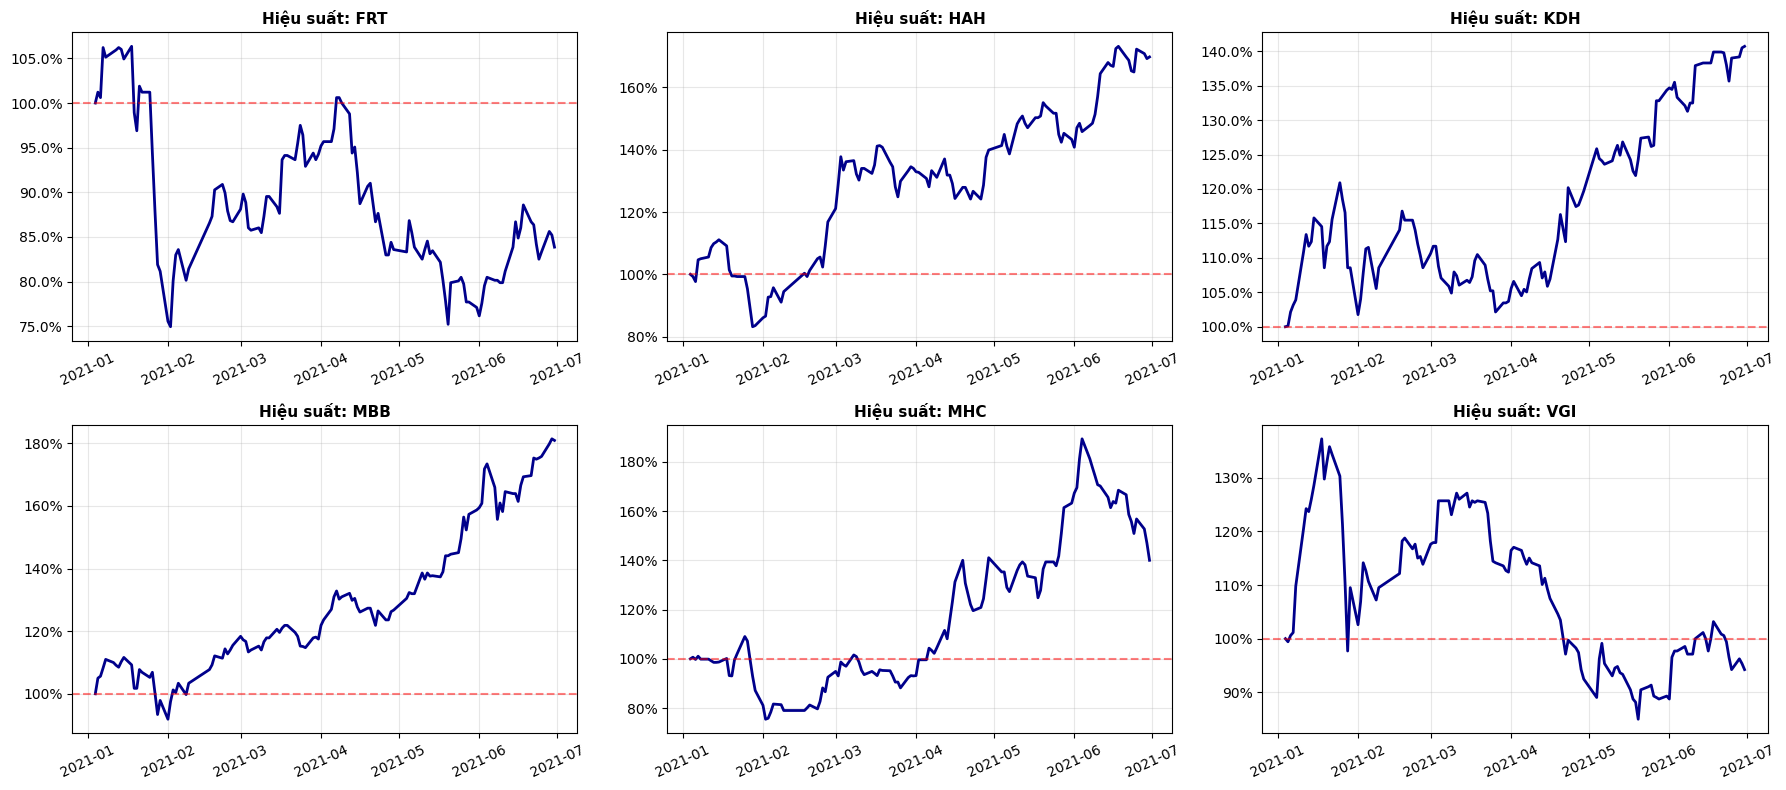



--- 🧠 TÍNH TOÁN VÀ DỰNG ĐỒ THỊ MẠNG LƯỚI THẦN KINH THỊ TRƯỜNG ---


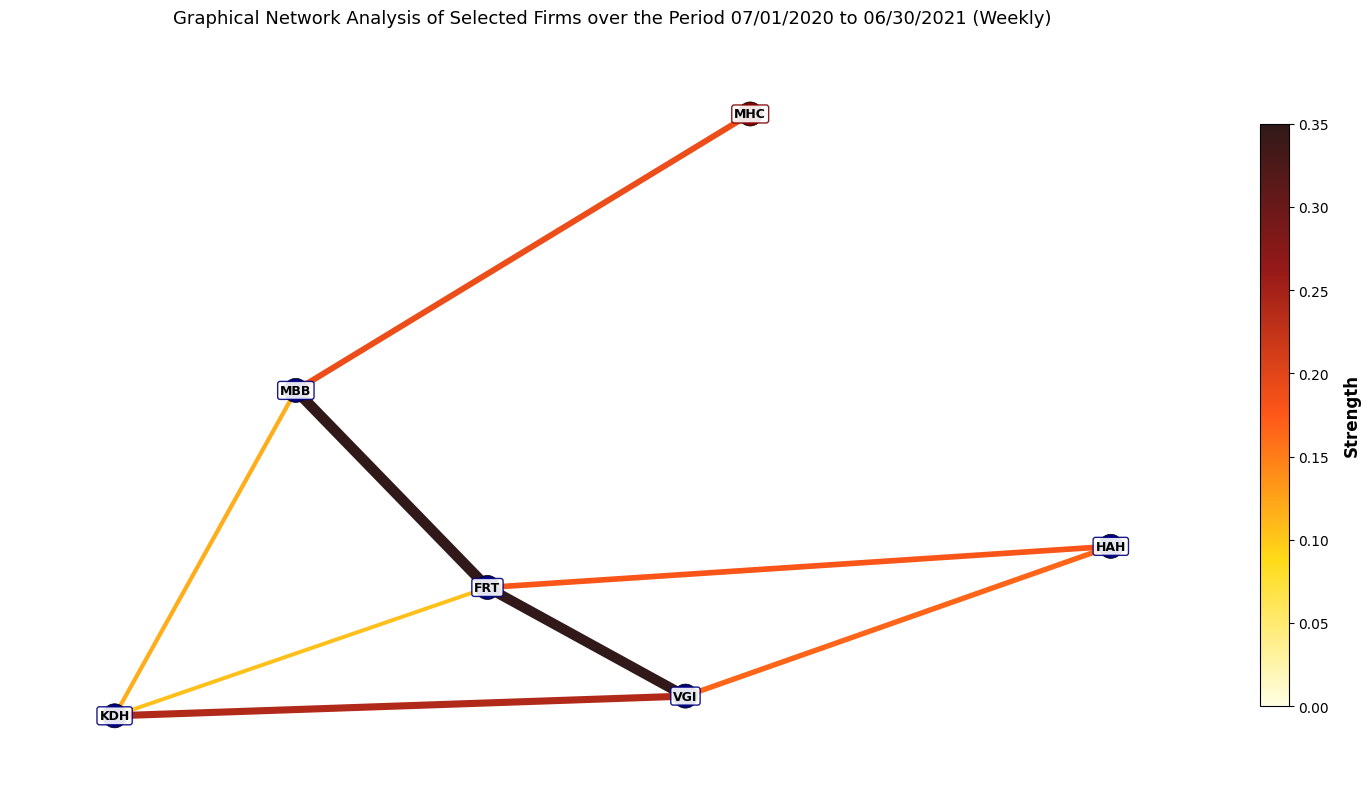

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import scipy.stats as ss
import networkx as nx
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import GraphicalLassoCV
from sklearn.cluster import AffinityPropagation
from sklearn.manifold import MDS

# ==============================================================================
# BẢNG CẤU HÌNH GIAI ĐOẠN 2 (Người dùng thiết lập thông số tại đây)
# ==============================================================================
start_date = '2020-07-01'      # Nhập ngày bắt đầu cho Giai đoạn 2 (YYYY-MM-DD)
end_date = '2021-06-30'        # Nhập ngày kết thúc cho Giai đoạn 2 (YYYY-MM-DD)

Sectors_chosen = []            # Chỉ định ngành (Ví dụ: ['Bank', 'Tech'] | [] là lấy TẤT CẢ)
drop_firm = []                 # Loại bỏ mã nhiễu (Ví dụ: ['FRC', 'RY'] | [] là giữ lại HẾT)

display_SumStat = True         # Bật/Tắt hiển thị bảng Thống kê mô tả
display_IndRet = True          # Bật/Tắt hiển thị biểu đồ lợi nhuận tích lũy từng mã
# ==============================================================================


# --- BƯỚC 1: BỘ LỌC DỮ LIỆU ĐẦU VÀO (DATA FILTERING ENGINE) ---
df_second = df_portfolio.copy()
df_second['Date'] = pd.to_datetime(df_second['Date'])

# 1. Cắt dữ liệu theo thời gian chỉ định
if start_date:
    df_second = df_second[df_second['Date'] >= pd.to_datetime(start_date)]
if end_date:
    df_second = df_second[df_second['Date'] <= pd.to_datetime(end_date)]

# 2. Lọc theo nhóm ngành nếu có thiết lập
if Sectors_chosen and 'Sector' in df_second.columns:
    df_second = df_second[df_second['Sector'].isin(Sectors_chosen)]

# 3. Loại bỏ các doanh nghiệp được chỉ định
if drop_firm:
    df_second = df_second[~df_second[symbol_col].isin(drop_firm)]

active_symbols = sorted(df_second[symbol_col].unique())
print(f"======================= SECOND DATA ANALYSIS =======================")
print(f"Thời gian phân tích: {start_date} đến {end_date}")
print(f"Số lượng cổ phiếu thỏa mãn bộ lọc: {len(active_symbols)} mã")
print(f"Danh sách mã: {active_symbols}\n")


# --- BƯỚC 2: HIỂN THỊ THỐNG KÊ MÔ TẢ (SUMMARY STATISTICS) ---
if display_SumStat and len(active_symbols) > 0:
    print("--- 📊 BẢNG THỐNG KÊ MÔ TẢ GIAI ĐOẠN 2 ---")
    df_pivot_ret = df_second.pivot(index='Date', columns=symbol_col, values='ret_simple')
    sum_stat = df_pivot_ret.describe().T
    sum_stat['skewness'] = df_pivot_ret.skew()
    sum_stat['kurtosis'] = df_pivot_ret.kurtosis()
    display(sum_stat.round(5))
    print("\n" + "-"*80 + "\n")


# --- BƯỚC 3: HIỂN THỊ BIỂU ĐỒ HIỆU SUẤT TÍCH LŨY TỪNG MÃ ---
if display_IndRet and len(active_symbols) > 0:
    print("--- 📈 ĐỒ THỊ TỶ SUẤT SINH LỜI GỘP TÍCH LŨY GIAI ĐOẠN 2 ---")
    df_second['gross_return'] = 1 + df_second['ret_simple'].fillna(0.0)
    df_second['cum_gross'] = df_second.groupby(symbol_col)['gross_return'].cumprod()
    
    num_plots = len(active_symbols)
    cols = min(3, num_plots)
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(18, 4 * rows))
    axes = np.array([axes]).flatten() if num_plots == 1 else axes.flatten()
        
    for i, symbol in enumerate(active_symbols):
        group = df_second[df_second[symbol_col] == symbol].sort_values('Date')
        axes[i].plot(group['Date'], group['cum_gross'], linewidth=2, color='darkblue')
        axes[i].axhline(1.0, color='red', linestyle='--', alpha=0.5)
        axes[i].set_title(f"Hiệu suất: {symbol}", fontsize=11, fontweight='bold')
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
        axes[i].grid(alpha=0.3)
        axes[i].tick_params(axis='x', rotation=25)
        
    for j in range(num_plots, len(axes)):
        fig.delaxes(axes[j])
    fig.tight_layout()
    plt.show()
    print("\n" + "="*80 + "\n")


# --- BƯỚC 4: CHUYỂN ĐỔI DỮ LIỆU TUẦN VÀ CHẠY MÔ HÌNH NHÂN TỐ THƯA (GRAPHICAL LASSO + AP + MDS) ---
if len(active_symbols) >= 3:
    print("--- 🧠 TÍNH TOÁN VÀ DỰNG ĐỒ THỊ MẠNG LƯỚI THẦN KINH THỊ TRƯỜNG ---")
    
    # 1. Chuẩn hóa dữ liệu đóng cửa tuần từ bộ lọc sạch mới
    df_daily_close = df_second.pivot(index='Date', columns=symbol_col, values='Close')
    data_weekly = df_daily_close.resample('W-FRI').last()
    weekly_ret_second = data_weekly.pct_change().dropna()
    
    symbols_graph = weekly_ret_second.columns.tolist()
    X_scaled = StandardScaler().fit_transform(weekly_ret_second)
    
    # 2. Chạy Graphical Lasso thu ma trận hiệp phương sai đảo thưa (Precision Matrix)
    gl_model = GraphicalLassoCV(cv=5, max_iter=2000)
    gl_model.fit(X_scaled)
    precision_matrix = gl_model.precision_
    
    # Tính ma trận tương quan điều kiện chuẩn hóa
    d = np.diag(precision_matrix)
    cond_corr = -precision_matrix / np.sqrt(np.outer(d, d))
    np.fill_diagonal(cond_corr, 1.0)
    
    # 3. Phân cụm tự động bằng Affinity Propagation
    ap_model = AffinityPropagation(random_state=42, max_iter=1000)
    cluster_labels = ap_model.fit_predict(X_scaled.T)
    unique_labels = np.unique(cluster_labels)
    num_clusters = len(unique_labels)
    
    # Định cấu hình bảng màu nút dạng 'jet' (Giống ảnh mẫu)
    cmap_nodes = cm.get_cmap('jet', num_clusters) if hasattr(cm, 'get_cmap') else bcm.colormaps['jet'].resampled(num_clusters)
    node_color_map = {label: cmap_nodes(i) for i, label in enumerate(unique_labels)}
    
    # 4. Giảm chiều không gian phi tuyến bằng MDS
    corr_dist = 1.0 - weekly_ret_second.corr().values
    mds_model = MDS(n_components=2, metric=True, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
    node_positions = mds_model.fit_transform(corr_dist)
    
    # 5. Khởi tạo cấu trúc NetworkX
    G = nx.Graph()
    for i, symbol in enumerate(symbols_graph):
        G.add_node(symbol, pos=(node_positions[i, 0], node_positions[i, 1]), 
                   color=node_color_map[cluster_labels[i]], cluster_id=cluster_labels[i])
        
    threshold = 0.02
    for i in range(len(symbols_graph)):
        for j in range(i + 1, len(symbols_graph)):
            weight = cond_corr[i, j]
            if weight > threshold:
                G.add_edge(symbols_graph[i], symbols_graph[j], weight=weight)
                
    # 6. Thiết lập thông số đồ họa cấu phần
    pos = nx.get_node_attributes(G, 'pos')
    edges = G.edges(data=True)
    edge_weights = [e[2]['weight'] for e in edges]
    
    # Tạo dải màu cạnh chuyển tiếp: Vàng nhạt -> Vàng -> Cam -> Đỏ -> Đen đặc
    colors_list = ["#FFFFE0", "#FFD700", "#FF4500", "#8B0000", "#1A0000"]
    custom_edge_cmap = mcolors.LinearSegmentedColormap.from_list("custom_financial", colors_list)
    
    v_min, v_max = 0.0, 0.35
    edge_widths = [1 + (w / v_max) * 6 for w in edge_weights] if len(edge_weights) > 0 else [1]*len(edges)
    
    # --- TIẾN HÀNH VẼ ĐỒ THỊ ---
    plt.figure(figsize=(15, 8))
    
    # Vẽ các cạnh (Hứng đối tượng để gán Colorbar rìa phải)
    edge_collection = nx.draw_networkx_edges(
        G, pos, edgelist=edges, edge_color=edge_weights, 
        edge_cmap=custom_edge_cmap, edge_vmin=v_min, edge_vmax=v_max, 
        width=edge_widths, alpha=0.9
    )
    
    # Vẽ các nút đệm
    node_colors_list = [G.nodes[node]['color'] for node in G.nodes]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors_list, node_size=300, edgecolors='black', linewidths=0.5)
    
    # Vẽ hộp chữ nhật màu trắng bao quanh tên cổ phiếu (Màu viền hộp đổi theo nhóm ngành)
    for node, (x, y) in pos.items():
        c_id = G.nodes[node]['cluster_id']
        box_color = node_color_map[c_id]
        plt.text(
            x, y, s=node, 
            bbox=dict(facecolor='white', edgecolor=box_color, boxstyle='round,pad=0.2', alpha=0.9),
            horizontalalignment='center', verticalalignment='center', 
            fontsize=9, fontname='sans-serif', fontweight='semibold'
        )
        
    # Tạo thanh đo Colorbar bên phải
    cbar = plt.colorbar(edge_collection, ax=plt.gca(), orientation='vertical', shrink=0.8, pad=0.03)
    cbar.set_label('Strength', fontsize=12, fontweight='bold', labelpad=10)
    cbar.ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
    
    # Định dạng tiêu đề đồ thị theo mốc thời gian cấu hình dạng MM/DD/YYYY
    s_title = pd.to_datetime(start_date).strftime('%m/%d/%Y') if start_date else 'Start'
    e_title = pd.to_datetime(end_date).strftime('%m/%d/%Y') if end_date else 'End'
    plt.title(f'Graphical Network Analysis of Selected Firms over the Period {s_title} to {e_title} (Weekly)', 
              fontsize=13, fontweight='regular', pad=20)
    
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("Hệ thống bỏ qua dựng đồ thị: Số lượng cổ phiếu còn lại sau lọc quá ít (Cần tối thiểu 3 mã).")